# 03 - VGG-Lite 训练

模型：VGGLite（5层卷积，VGG风格，~1.5M参数）
目标：验证深层网络+小卷积核堆叠策略在FER2013上的表现

控制方式：
- **开始训练**: 运行下方训练Cell
- **暂停训练**: 点击 Jupyter 停止按钮(■)，断点自动保存
- **继续训练**: 运行下方Checkpoint选择Cell，选择断点后运行训练Cell

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from pathlib import Path

from training.trainer import (
    PROJECT_ROOT, load_config, set_seed, Trainer,
)
from data.dataloader import create_dataloaders
from training.checkpoint import select_checkpoint_widget
from models.vgg_lite import VGGLite

config = load_config()
set_seed(config['seed'])

MODEL_NAME = 'vgg_lite'
model_config = config['models'][MODEL_NAME]
CLASS_NAMES = config['data']['class_names']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

activation = model_config.get('activation', config['training']['activation'])

print(f"设备: {device}")
print(f"模型: {MODEL_NAME} | 激活函数: {activation}")
print(f"配置: {model_config}")

设备: cuda
模型: vgg_lite | 激活函数: relu
配置: {'learning_rate': 0.0003, 'batch_size': 128, 'num_epochs': 30, 'dropout': 0.5, 'activation': 'relu'}


## 1. Checkpoint 选择（继续训练时使用）

In [ ]:
# 选择 Checkpoint，点击「确认选择」后运行下一个 Cell
# 选择结果会自动写入 RESUME_FROM 变量
select_checkpoint_widget(MODEL_NAME)

## 2. 准备数据 & 构建模型

In [3]:
# RESUME_FROM 由上方 checkpoint 选择控件自动设置
# - 选了 checkpoint → 自动恢复训练
# - 选了「从头开始训练」→ RESUME_FROM = None
# 如需手动覆盖: RESUME_FROM = None  (或指定路径)

RESUME_FROM = globals().get('RESUME_FROM', None)

if RESUME_FROM:
    meta = Trainer.load_checkpoint_metadata(RESUME_FROM)
    print(f"恢复训练: {RESUME_FROM.name}")
    if meta:
        print(f"  epoch={meta['epoch']}  val_acc={meta['val_acc']:.4f}  best_val_acc={meta['best_val_acc']:.4f}")
else:
    print("从头开始训练")

train_loader, val_loader, test_loader, _ = create_dataloaders(config, MODEL_NAME)
print(f"训练集: {len(train_loader.dataset)}, 验证集: {len(val_loader.dataset)}, 测试集: {len(test_loader.dataset)}")

model = VGGLite(
    num_classes=config['data']['num_classes'],
    dropout=model_config['dropout'],
    activation=activation,
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    config=config,
    model_name=MODEL_NAME,
    device=device,
    
)

if RESUME_FROM:
    trainer.load_checkpoint(RESUME_FROM)

print(f"总参数量: {trainer.total_params:,}")

恢复训练: local_best.pth
  epoch=81  val_acc=0.6264  best_val_acc=0.6264
DataLoader: batch_size=128, train_workers=4(prefetch=6), eval_workers=0, pin_memory=True
  class_balanced_sampling: enabled (min_weight=0.5684, max_weight=9.4066, ratio=16.5x)
训练集: 28709, 验证集: 3589, 测试集: 3589
  loss: CBFocalLoss(gamma=2.0, beta=0.999)
总参数量: 5,407,687


## 3. 开始训练

> 按 **停止按钮(■)** 可随时暂停，断点自动保存

In [4]:
# fit(N) = 本次训练 N 轮（无上限，可反复调用续训）
# 从头训练: fit(60)  |  续训 10 轮: fit(10)
history = trainer.fit(60)


模型: vgg_lite | 参数量: 5,407,687
设备: cuda | AMP: True | Compile: False
   matmul_precision: high
权重已训练: 81 轮 | 本次续训: 60 轮 → 训练至第 141 轮
之前累计用时: 6m41s



[Epoch 82 | 本轮 1/60] Train: 0.6073/0.6150 | Val: 0.6203/0.6222 (T5:0.9916) | LR: 0.000050 | 25s | ETA 5m11s *


[Epoch 83 | 本轮 2/60] Train: 0.6444/0.5985 | Val: 0.6210/0.6130 (T5:0.9891) | LR: 0.000299 | 4s | ETA 5m05s


[Epoch 84 | 本轮 3/60] Train: 0.6438/0.5952 | Val: 0.6470/0.6052 (T5:0.9877) | LR: 0.000297 | 4s | ETA 4m59s


[Epoch 85 | 本轮 4/60] Train: 0.6360/0.5988 | Val: 0.6279/0.6160 (T5:0.9863) | LR: 0.000293 | 4s | ETA 4m53s


...

[Epoch 126 | 本轮 45/60] Train: 0.5636/0.6292 | Val: 0.6051/0.6291 (T5:0.9880) | LR: 0.000261 | 4s | ETA 1m15s


[Epoch 127 | 本轮 46/60] Train: 0.5700/0.6313 | Val: 0.5908/0.6191 (T5:0.9900) | LR: 0.000256 | 4s | ETA 1m10s


[Epoch 128 | 本轮 47/60] Train: 0.5585/0.6310 | Val: 0.6161/0.6241 (T5:0.9880) | LR: 0.000250 | 4s | ETA 1m05s


[Epoch 129 | 本轮 48/60] Train: 0.5591/0.6288 | Val: 0.5738/0.6286 (T5:0.9922) | LR: 0.000244 | 4s | ETA 1m00s


[Epoch 130 | 本轮 49/60] Train: 0.5516/0.6375 | Val: 0.5788/0.6280 (T5:0.9889) | LR: 0.000238 | 4s | ETA 55s

Early stopping at [Epoch 130 | 本轮 49/60], best val_acc: 0.6367

训练完成 | 训练至第 130 轮 | 最优 val_acc: 0.6367 | 总用时: 10m50s
训练历史: D:\emotion_recognition\training\logs\vgg_lite\history.json


## 4. 训练曲线

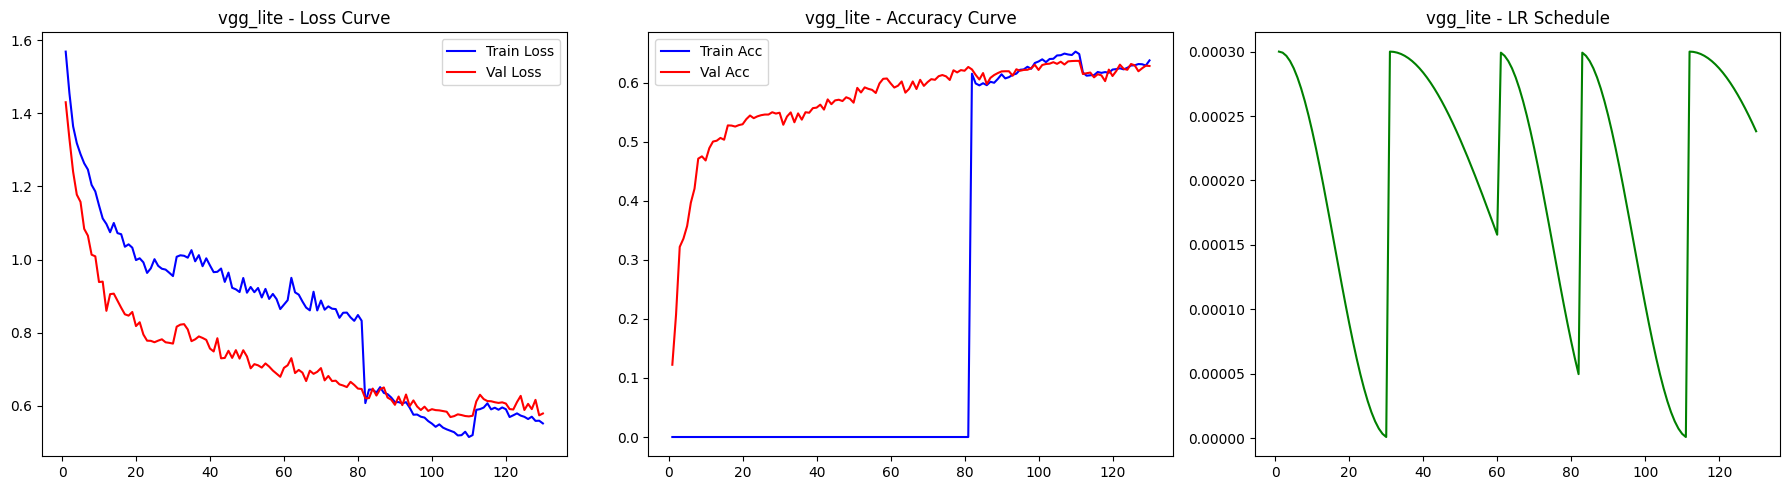

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
axes[0].set_title(f'{MODEL_NAME} - Loss Curve'); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
axes[1].set_title(f'{MODEL_NAME} - Accuracy Curve'); axes[1].legend()

axes[2].plot(epochs_range, history['lr'], 'g-')
axes[2].set_title(f'{MODEL_NAME} - LR Schedule')

plt.tight_layout()
curve_dir = PROJECT_ROOT / 'analysis' / 'training_curves'
curve_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(curve_dir / f'{MODEL_NAME}_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 测试集评估

分类报告:
              precision    recall  f1-score   support

       Angry       0.58      0.61      0.60       491
     Disgust       0.89      0.73      0.80        55
        Fear       0.53      0.24      0.33       528
       Happy       0.89      0.86      0.88       879
         Sad       0.47      0.61      0.53       594
    Surprise       0.72      0.83      0.77       416
     Neutral       0.62      0.69      0.66       626

    accuracy                           0.66      3589
   macro avg       0.67      0.65      0.65      3589
weighted avg       0.66      0.66      0.65      3589



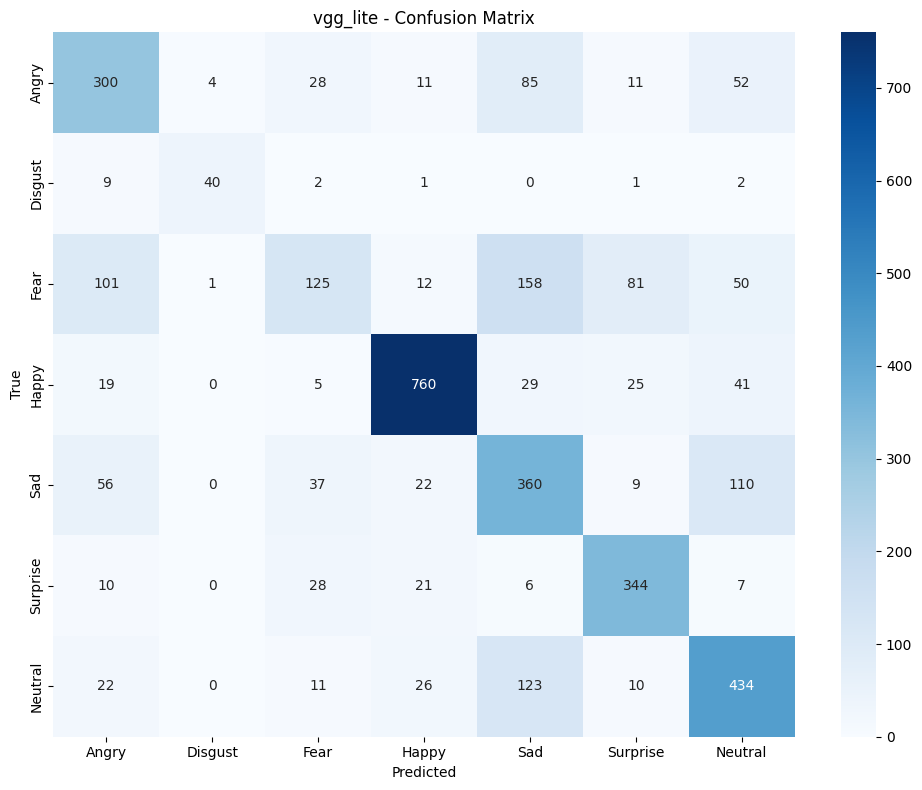

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 加载全局最优模型（跨会话最佳），回退到本轮最佳
if trainer.global_best_model_state:
    trainer.model.load_state_dict(trainer.global_best_model_state)
elif trainer.best_model_state:
    trainer.model.load_state_dict(trainer.best_model_state)
trainer.model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = trainer.model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("分类报告:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

# 混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'{MODEL_NAME} - Confusion Matrix')
plt.tight_layout()
cm_dir = PROJECT_ROOT / 'analysis' / 'confusion_matrices'
cm_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(cm_dir / f'{MODEL_NAME}_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC 曲线

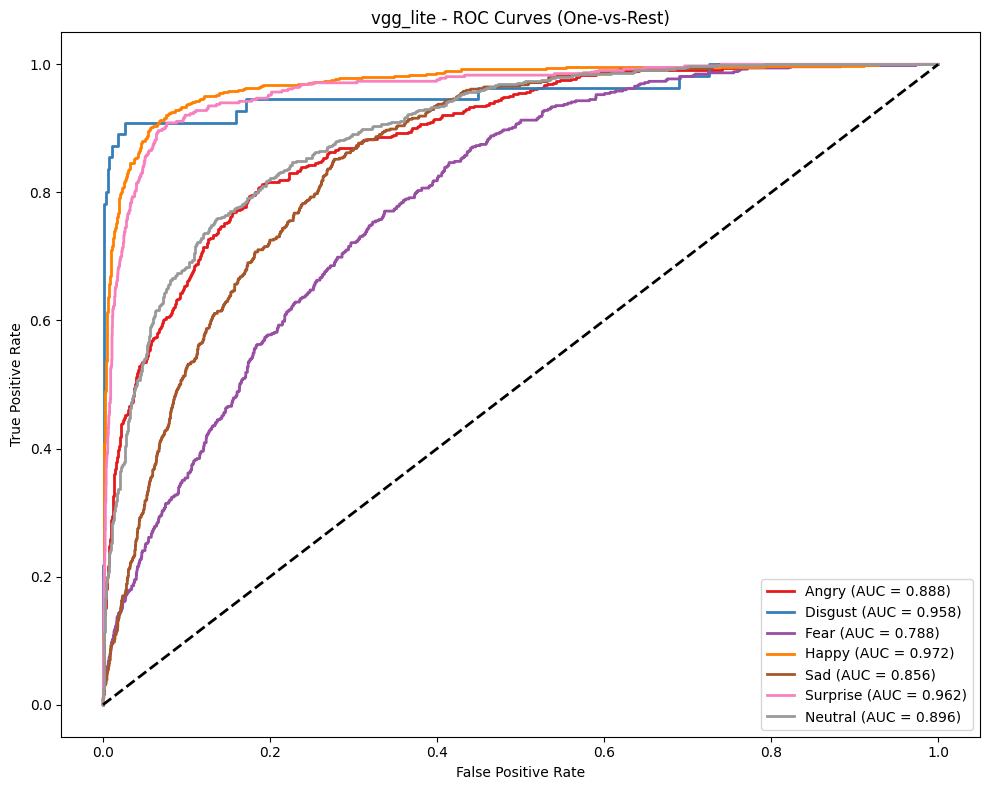

In [7]:
y_true_bin = label_binarize(all_labels, classes=list(range(len(CLASS_NAMES))))

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Set1(np.linspace(0, 1, len(CLASS_NAMES)))

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'{MODEL_NAME} - ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right')
plt.tight_layout()
roc_dir = PROJECT_ROOT / 'analysis' / 'roc_curves'
roc_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(roc_dir / f'{MODEL_NAME}_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 导出最终模型到推理目录

In [8]:
src = PROJECT_ROOT / 'training' / 'checkpoints' / MODEL_NAME / 'global_best.pth'
dst = PROJECT_ROOT / 'inference' / 'saved_models' / f'{MODEL_NAME}_best.pth'
dst.parent.mkdir(parents=True, exist_ok=True)

if src.exists():
    shutil.copy2(src, dst)
    print(f"模型已复制: {src} -> {dst}")
else:
    print(f"警告: 最优模型不存在 {src}")

模型已复制: D:\emotion_recognition\training\checkpoints\vgg_lite\global_best.pth -> D:\emotion_recognition\inference\saved_models\vgg_lite_best.pth


## 8. 一键导出分析图表到 analysis_saved/

In [9]:
# 将从 §4-6 生成的训练曲线、混淆矩阵、ROC 曲线复制到
# analysis_saved/{MODEL_NAME}_{时间戳}/，文件保持原名

from datetime import datetime

export_root = PROJECT_ROOT / 'analysis_saved'
export_root.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
export_dir = export_root / f'{MODEL_NAME}_{ts}'
export_dir.mkdir(parents=True, exist_ok=True)

# 源文件路径
sources = [
    PROJECT_ROOT / 'analysis' / 'training_curves' / f'{MODEL_NAME}_training_curves.png',
    PROJECT_ROOT / 'analysis' / 'confusion_matrices' / f'{MODEL_NAME}_cm.png',
    PROJECT_ROOT / 'analysis' / 'roc_curves' / f'{MODEL_NAME}_roc.png',
]

copied = 0
for src in sources:
    if src.exists():
        shutil.copy2(src, export_dir)
        copied += 1
        print(f'✅ 已复制: {src.name}')
    else:
        print(f'⚠️ 未找到: {src.name}')

print(f'\n共导出 {copied}/3 张图到: {export_dir}')

✅ 已复制: vgg_lite_training_curves.png
✅ 已复制: vgg_lite_cm.png
✅ 已复制: vgg_lite_roc.png

共导出 3/3 张图到: D:\emotion_recognition\analysis_saved\vgg_lite_20260519_233331
